# # Flight Delay Prediction: Binary Classification
# **Goal:** Predict if a flight will be delayed by >= 15 minutes.



In [1]:
# %% [1] Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
# %% [2] Load Data
df = pd.read_csv('../Data/FlightWeatherData.csv')
print(f"Dataset Loaded. Shape: {df.shape}")

/var/folders/n2/hk2krs0x0vq5tc8b04ns_n1w0000gn/T/ipykernel_51792/2168829649.py:2: DtypeWarning: Columns (0: SCH_OP_UNIQUE_CARRIER, 1: SCH_OP_CARRIER, 2: CANCELLATION_CODE, 3: DIV1_AIRPORT, 4: DIV1_TAIL_NUM, 5: DIV2_AIRPORT, 6: DIV2_TAIL_NUM, 7: DIV3_AIRPORT, 8: DIV3_TAIL_NUM, 9: tmpf, 10: dwpf, 11: relh, 12: sknt, 13: alti, 14: mslp, 15: vsby, 16: feel) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Data/FlightWeatherData.csv')


Dataset Loaded. Shape: (7736770, 154)


In [3]:
# 2. List the columns that the error message complained about
# Want to force these to be numeric (float)
numeric_columns_to_fix = [
    'tmpf', 'dwpf', 'relh', 'sknt', 'alti', 'mslp', 'vsby', 'feel'
]

for col in numeric_columns_to_fix:
    if col in df.columns:
        # errors='coerce' turns "N/A", " ", or "Unknown" into NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. For the Carrier/Airport columns, to ensure they are strings 
# (This prevents them from being treated as mixed integers/strings)
categorical_columns_to_fix = [
    'SCH_OP_UNIQUE_CARRIER', 'SCH_OP_CARRIER', 'CANCELLATION_CODE', 
    'DIV1_AIRPORT', 'DIV1_TAIL_NUM', 'DIV2_AIRPORT', 'DIV2_TAIL_NUM', 
    'DIV3_AIRPORT', 'DIV1_TAIL_NUM'
]

for col in categorical_columns_to_fix:
    if col in df.columns:
        df[col] = df[col].astype(str).replace(['nan', 'None', 'nan', ''], np.nan)

print("Data Loaded and Types Corrected.")

Data Loaded and Types Corrected.


In [ ]:
# %% [3] Data Cleaning
def clean_flight_data(data):

    df_clean = data.copy()

    leakage_cols = [
        'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DELAY_GROUP',
        'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'ARR_DELAY_GROUP',
        'DEP_TIME', 'ARR_TIME',
        'TAXI_OUT', 'TAXI_IN', 'WHEELS_OFF', 'WHEELS_ON',
        'ACTUAL_ELAPSED_TIME', 'AIR_TIME',
        'DIV_REACHED_DEST', 'DIV_ACTUAL_ELAPSED_TIME', 'DIV_ARR_DELAY',
        'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 
        'LATE_AIRCRAFT_DELAY'
    ]

    df_clean.drop(columns=[c for c in leakage_cols if c in df_clean.columns], inplace=True)

    # DROP NON-PREDICTIVE COLUMNS (IDs and Names)
    # These are unique identifiers that don't help generalization
    drop_cols = [
        'MKT_CARRIER_FL_NUM', 'OP_CARRIER_FL_NUM', 'TAIL_NUM', 'OP_CARRIER_FL_NUM',
        'ORIGIN_CITY_NAME', 'DEST_CITY_NAME', 'METAR', 'STATION', 'VALID'
    ]
    df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], inplace=True)


    # HANDLE MISSING VALUES
    # For numerical weather data, median was used to avoid outlier influence
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

    # For categorical data, we'll fill with 'Unknown'
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

    # CONVERT TARGET TO BINARY (Ensuring DEP_DEL15 is 0 or 1)
    if 'DEP_DEL15' in df_clean.columns:
        df_clean['DEP_DEL15'] = df_clean['DEP_DEL15'].astype(int)
    
    return df_clean

df_cleaned = clean_flight_data(df)
print("Cleaning Complete.")

# if anything appears from this there is leakage.
print([col for col in df_cleaned.columns if 'DELAY' in col])

/var/folders/n2/hk2krs0x0vq5tc8b04ns_n1w0000gn/T/ipykernel_51792/3027850634.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns


Cleaning Complete.
[]


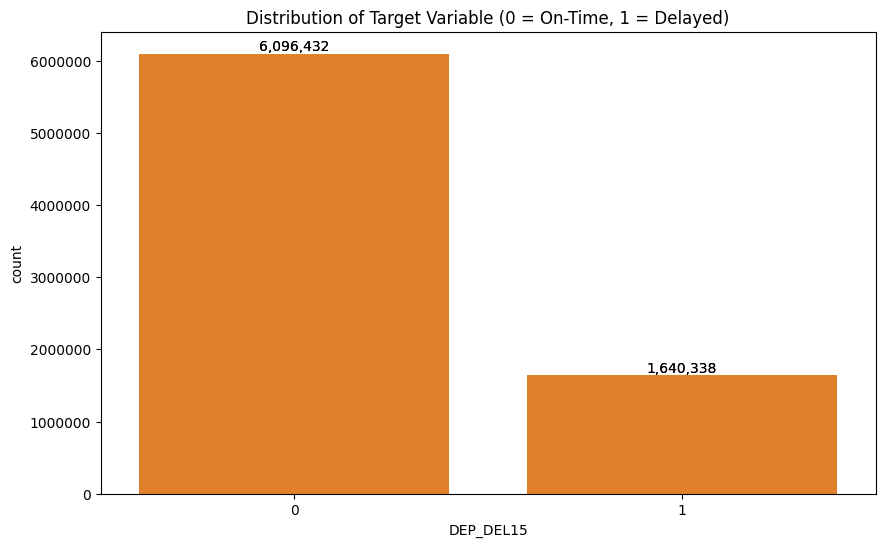

In [14]:
# %% [4] Exploratory Data Analysis (EDA)
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='DEP_DEL15', data=df_cleaned) # Assign to 'ax'

sns.countplot(x='DEP_DEL15', data=df_cleaned)
plt.title('Distribution of Target Variable (0 = On-Time, 1 = Delayed)')
plt.ticklabel_format(style='plain', axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}') # Adds commas for readability

plt.show()

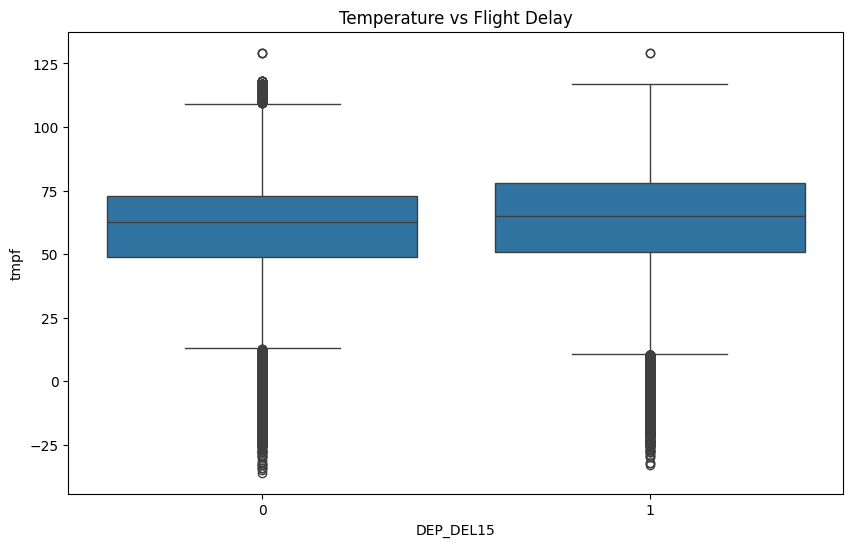

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='DEP_DEL15', y='tmpf', data=df_cleaned)
plt.title('Temperature vs Flight Delay')
plt.show()

#Are delays more common in extreme temps?

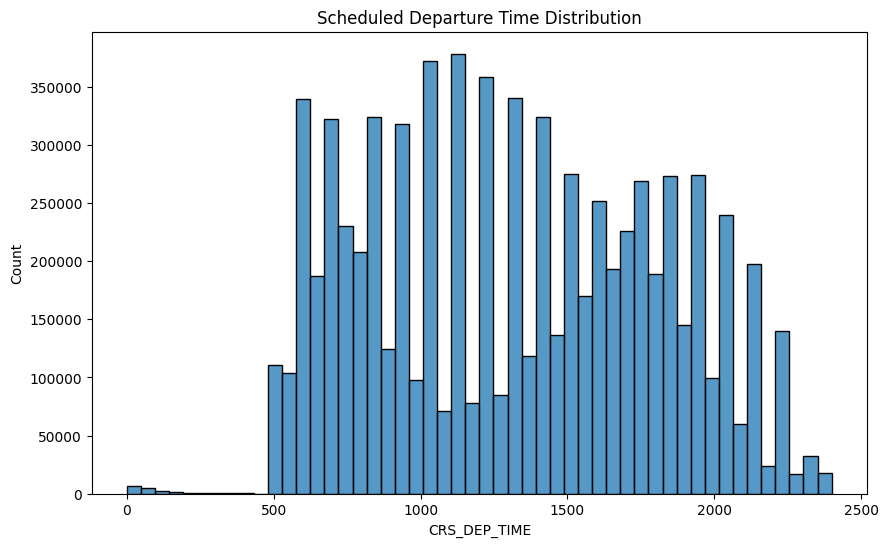

<Axes: xlabel='CRS_DEP_TIME', ylabel='Count'>

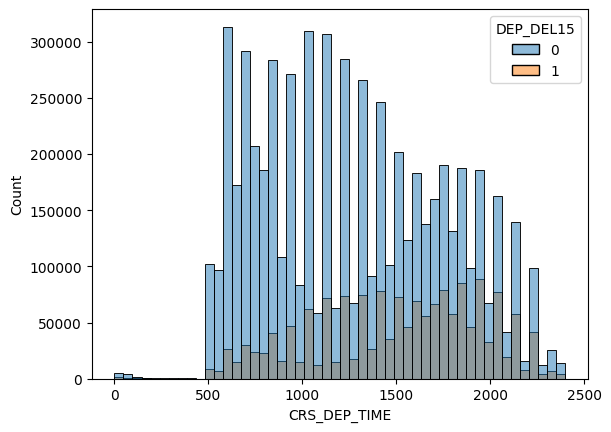

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_cleaned['CRS_DEP_TIME'], bins=50)
plt.title('Scheduled Departure Time Distribution')
plt.show()

#second graph: Are late flights more delayed?
sns.histplot(data=df_cleaned, x='CRS_DEP_TIME', hue='DEP_DEL15', bins=50)

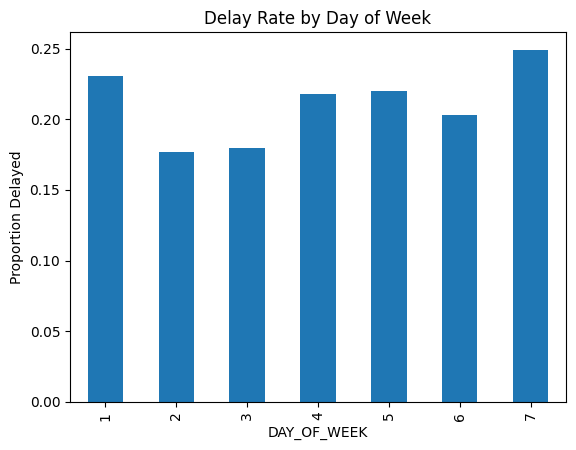

In [24]:
delay_by_day = df_cleaned.groupby('DAY_OF_WEEK')['DEP_DEL15'].mean()

delay_by_day.plot(kind='bar')
plt.title('Delay Rate by Day of Week')
plt.ylabel('Proportion Delayed')
plt.show()

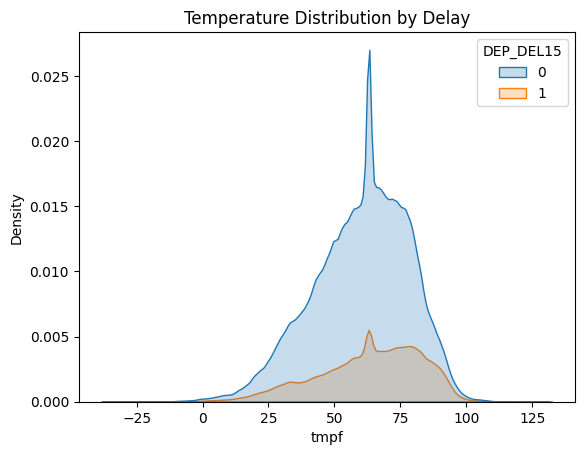

In [25]:
sns.kdeplot(data=df_cleaned, x='tmpf', hue='DEP_DEL15', fill=True)
plt.title('Temperature Distribution by Delay')
plt.show()

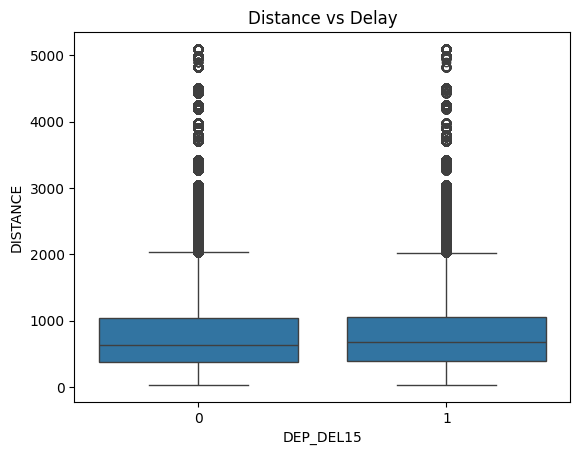

In [26]:
sns.boxplot(x='DEP_DEL15', y='DISTANCE', data=df_cleaned)
plt.title('Distance vs Delay')
plt.show()

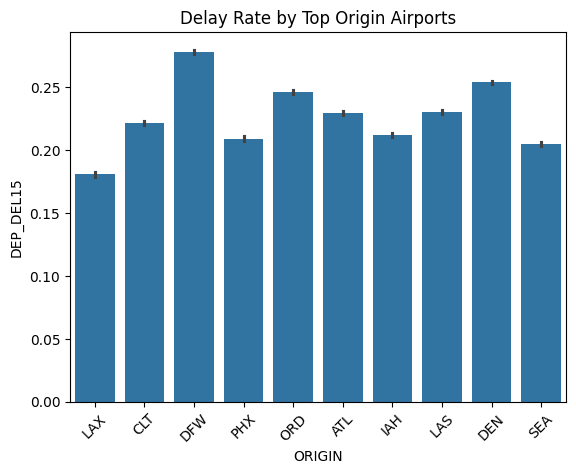

In [27]:
top_airports = df_cleaned['ORIGIN'].value_counts().head(10).index
subset = df_cleaned[df_cleaned['ORIGIN'].isin(top_airports)]

sns.barplot(data=subset, x='ORIGIN', y='DEP_DEL15')
plt.title('Delay Rate by Top Origin Airports')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Correlation with Target
corr = df_cleaned.corr(numeric_only=True)['DEP_DEL15'].sort_values(ascending=False)
print(corr.head(15))

DEP_DEL15               1.000000
CRS_DEP_TIME            0.194128
CRS_ARR_TIME            0.164383
sknt                    0.078894
tmpf                    0.068277
feel                    0.064928
TOTAL_ADD_GTIME         0.047500
LONGEST_ADD_GTIME       0.046061
dwpf                    0.041900
DAY_OF_WEEK             0.025789
lon                     0.025470
MONTH                   0.024334
QUARTER                 0.021775
DIVERTED                0.017389
DIV_AIRPORT_LANDINGS    0.013884
Name: DEP_DEL15, dtype: float64


Available columns in your file are: ['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'MKT_UNIQUE_CARRIER', 'BRANDED_CODE_SHARE', 'MKT_CARRIER_AIRLINE_ID', 'MKT_CARRIER', 'SCH_OP_UNIQUE_CARRIER', 'SCH_OP_CARRIER_AIRLINE_ID', 'SCH_OP_CARRIER', 'SCH_OP_CARRIER_FL_NUM', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID']... (showing first 20)


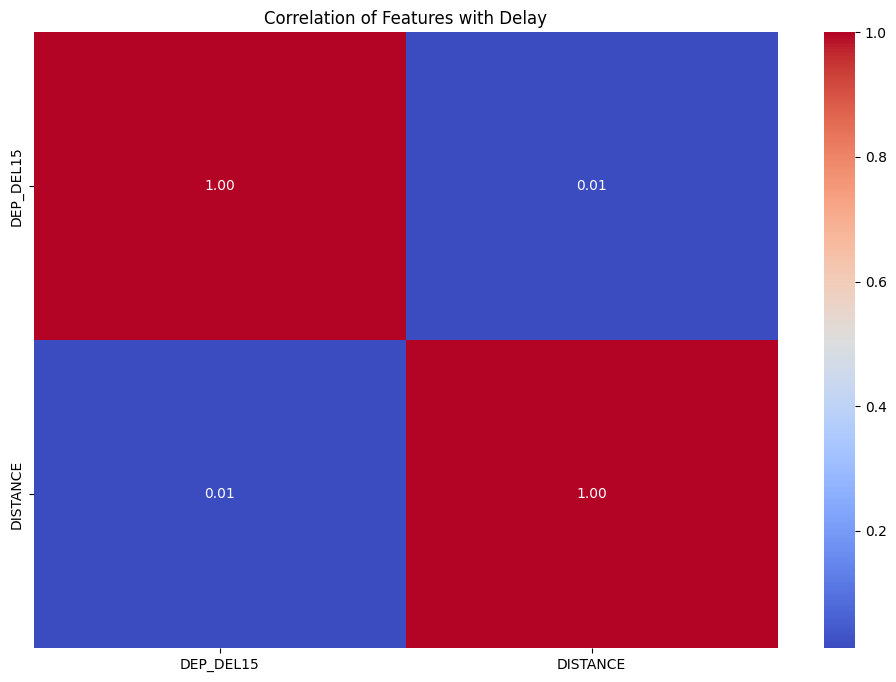

In [ ]:
# 1. Define the columns you WANT to see (using the ALL CAPS from your header)
target_cols = ['DEP_DEL15', 'tmpF', 'SKNT', 'VSBY', 'RELH', 'DISTANCE'] 
# Note: Check if weather columns are 'tmpf' or 'tmpF' by running print(df_cleaned.columns)

# 2. Safety Check: Only select columns that actually exist in the DataFrame
existing_cols = [c for c in target_cols if c in df_cleaned.columns]

# 3. Prints a warning if some columns were missing (for debug heko)
missing_cols = set(target_cols) - set(existing_cols)
if missing_cols:
    print(f"Warning: The following columns were not found and will be skipped: {missing_cols}")
    print(f"Available columns in your file are: {df_cleaned.columns.tolist()[:20]}... (showing first 20)")

# 4. Perform the Heatmap only if we have at least 2 columns to compare
if len(existing_cols) > 1:
    plt.figure(figsize=(12, 8))
    corr_subset = df_cleaned[existing_cols].corr()
    sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation of Features with Delay')
    plt.show()
else:
    print("Error: Not enough valid columns found to generate a correlation heatmap.")


#----------old code dont use -------
# # Correlation Heatmap (Looking at Weather vs Delay)
# plt.figure(figsize=(15, 10))
# # Selecting a subset of columns for readability
# corr_subset = df_cleaned[['DEP_DEL15', 'tmpf', 'sknt', 'vsby', 'relh', 'distance']].corr()
# sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation of Weather Features with Delay')
# plt.show()

In [16]:
# %% [5] Feature Engineering & Preprocessing

def preprocess_for_ml(data):
    df_ml = data.copy()
    
    # Handle date columns
    if 'FL_DATE' in df_ml.columns:
        df_ml['FL_DATE'] = pd.to_datetime(df_ml['FL_DATE'], errors='coerce')
        df_ml['MONTH'] = df_ml['FL_DATE'].dt.month
        df_ml['DAY_OF_WEEK'] = df_ml['FL_DATE'].dt.dayofweek
        df_ml.drop(columns=['FL_DATE'], inplace=True)
    
    # Encode categorical variables
    le = LabelEncoder()
    cat_features = ['ORIGIN', 'DEST', 'MKT_CARRIER', 'DISTANCE_GROUP']
    
    for col in cat_features:
        if col in df_ml.columns:
            df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    
    # Remove  leftover string columns
    df_ml = df_ml.select_dtypes(exclude=['object', 'string'])
    
    # Drop bad columns
    df_ml = df_ml.dropna(axis=1, how='all')
    
    nunique = df_ml.nunique()
    constant_cols = nunique[nunique <= 1].index
    df_ml = df_ml.drop(columns=constant_cols)
    
    df_ml = df_ml.dropna()
    
    return df_ml, df_ml.columns.drop('DEP_DEL15', errors='ignore').tolist()

df_final, feature_cols = preprocess_for_ml(df_cleaned)

In [ ]:
# %% [6] Model Training (Random Forest Classifier)

X = df_final[feature_cols]
y = df_final['DEP_DEL15']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {X_train.shape[0]} samples. Testing on {X_test.shape[0]} samples.")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42,
    
    #to handle class imbalance better since there are alot less delayed flights than on time flights
    class_weight='balanced'
)
model.fit(X_train, y_train)

Training on 6189416 samples. Testing on 1547354 samples.


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.60      0.71   1219286
           1       0.32      0.69      0.43    328068

    accuracy                           0.62   1547354
   macro avg       0.60      0.65      0.57   1547354
weighted avg       0.76      0.62      0.65   1547354


--- Confusion Matrix ---
          Predicted 0  Predicted 1
Actual 0       731265       488021
Actual 1       101551       226517


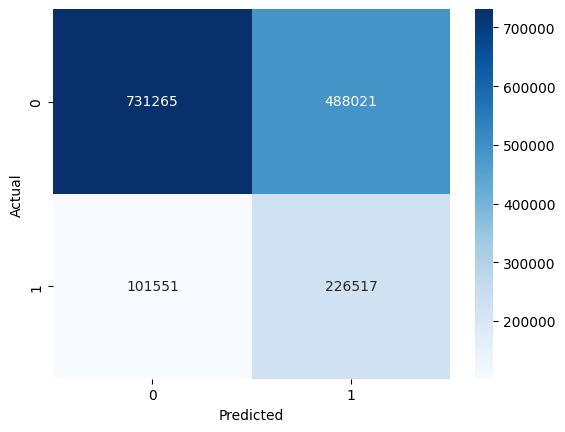

In [18]:
# %% [7] Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
print(df_cm)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
# debugging outputs
# print(feature_cols[:50])

# corr = df_final.corr(numeric_only=True)['DEP_DEL15'].sort_values(ascending=False)
# print(corr.head(10))

# importances = pd.Series(model.feature_importances_, index=feature_cols)
# print(importances.sort_values(ascending=False).head(10))

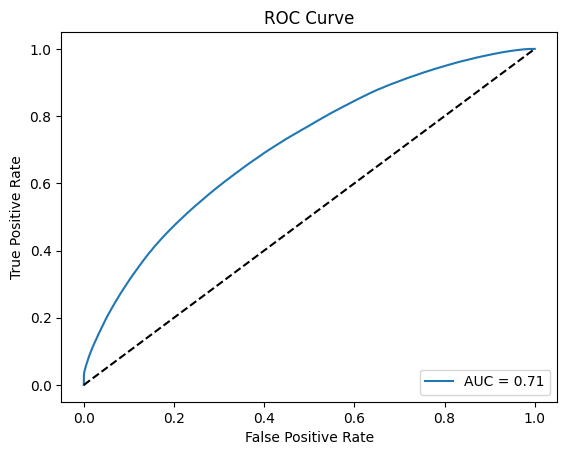

In [19]:
# AUC-ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt_auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {plt_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC Curve')
plt.show()

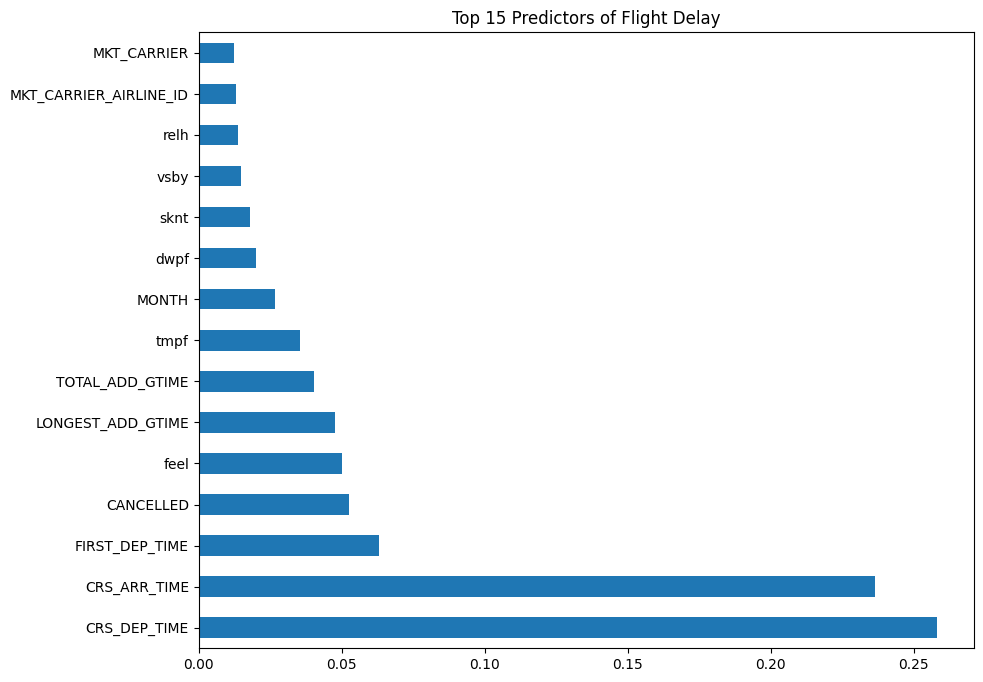

CRS_DEP_TIME         0.258096
CRS_ARR_TIME         0.236426
FIRST_DEP_TIME       0.063194
CANCELLED            0.052711
feel                 0.050085
LONGEST_ADD_GTIME    0.047503
TOTAL_ADD_GTIME      0.040423
tmpf                 0.035442
MONTH                0.026836
dwpf                 0.019986
dtype: float64


In [20]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances.nlargest(15).plot(kind='barh', figsize=(10, 8))
plt.title('Top 15 Predictors of Flight Delay')
plt.show()
print(importances.sort_values(ascending=False).head(10))